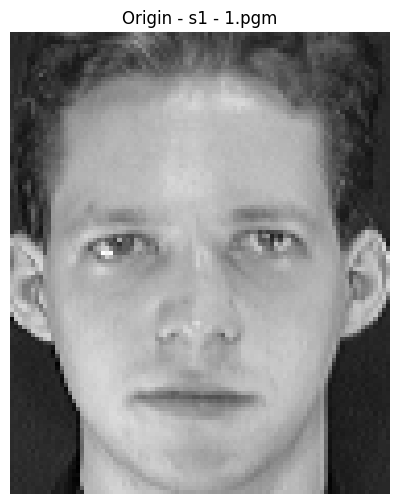

Kích thước ảnh gốc: (112, 92)
Giá trị pixel: min=11, max=234


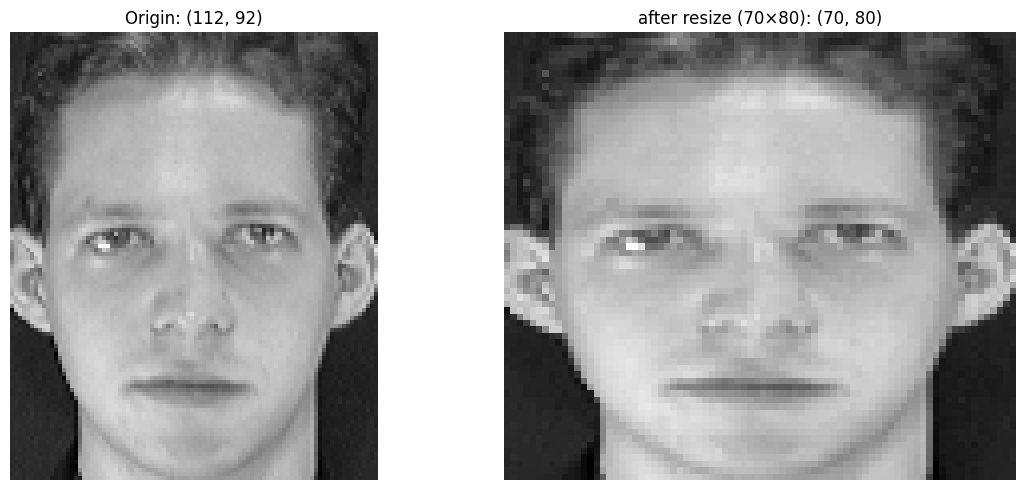

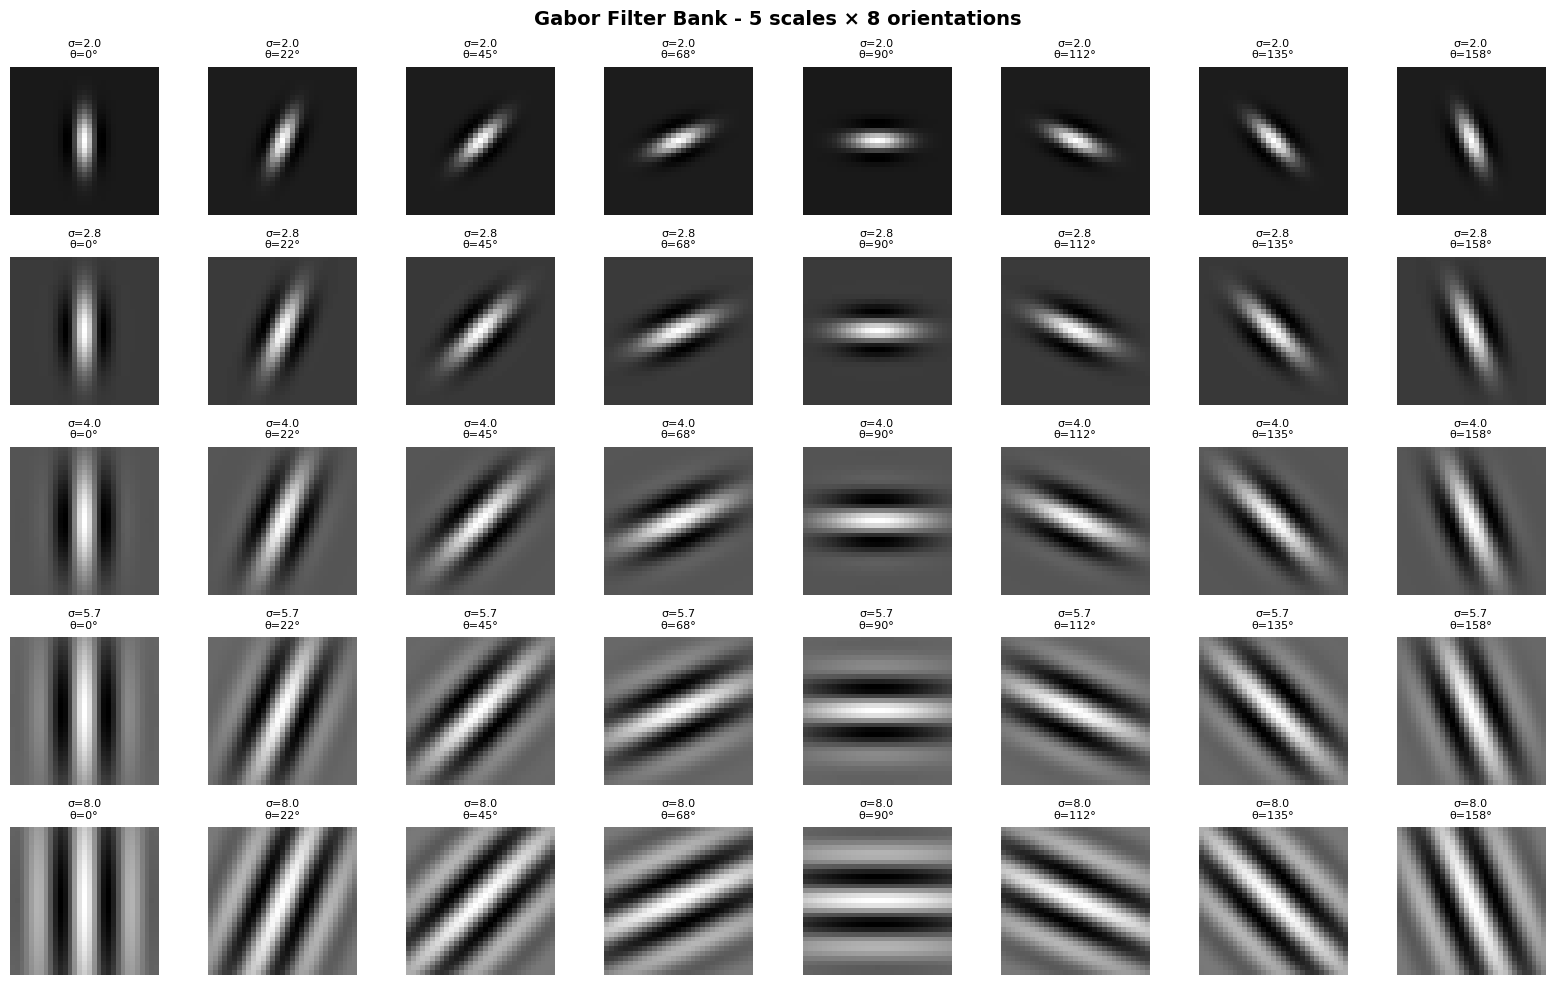

Tổng số filters: 40


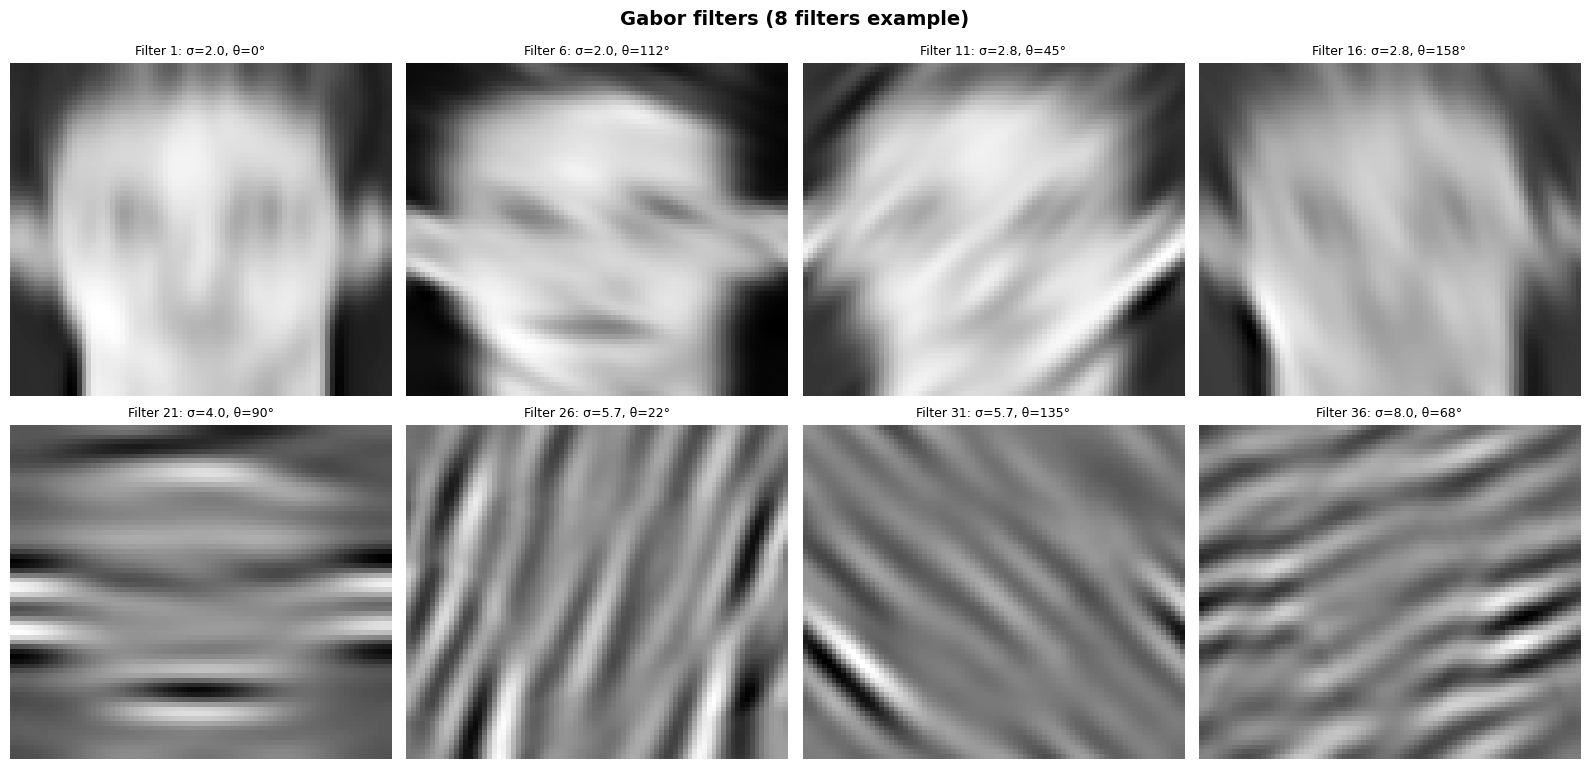

Số lượng feature maps: 40
Kích thước mỗi feature map: (70, 80)


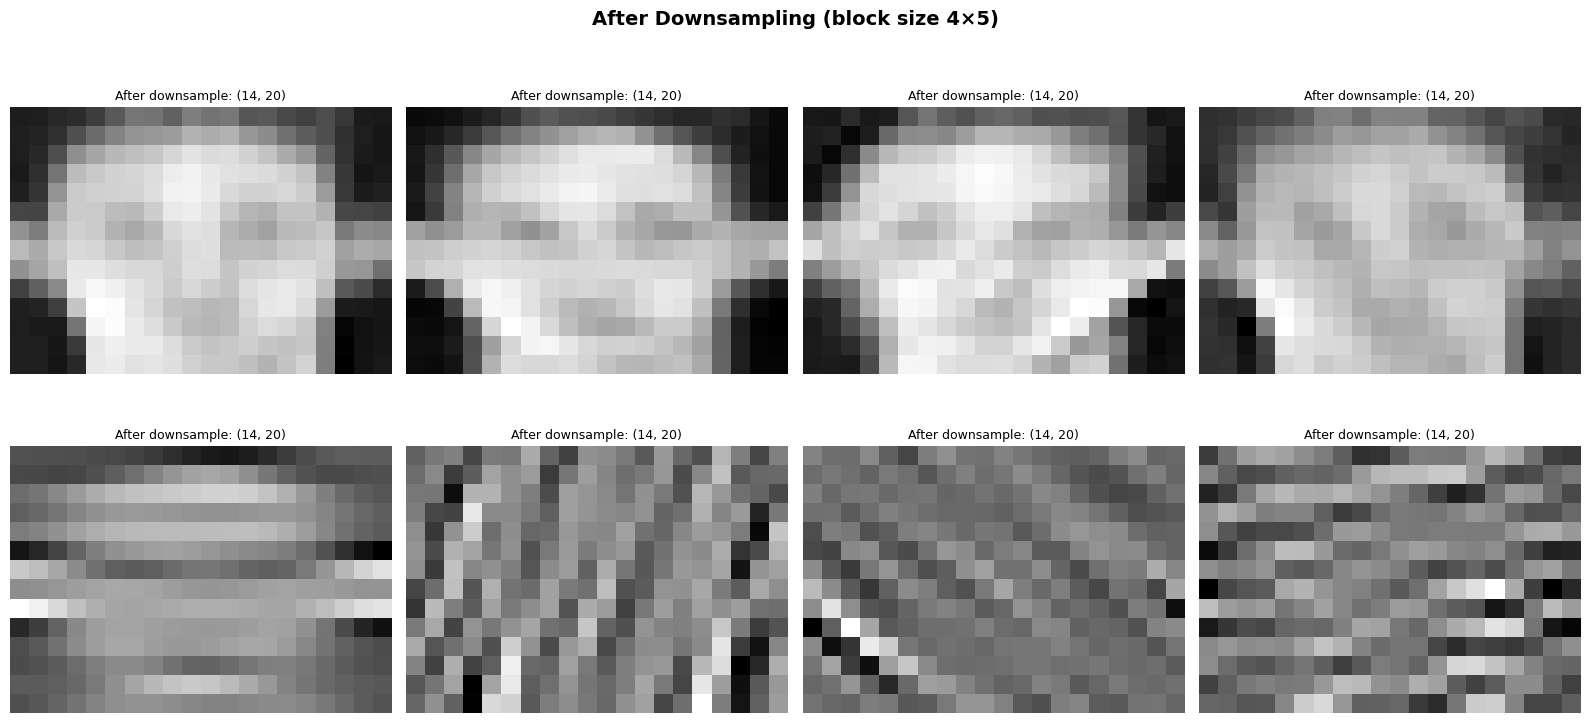


GIẢI THÍCH QUÁ TRÌNH DOWNSAMPLING
Feature map gốc: (70, 80) (70×80)
Block size: 5 (chiều cao) × 4 (chiều rộng)
Số block theo chiều cao: 70 ÷ 5 = 14 blocks
Số block theo chiều rộng: 80 ÷ 4 = 20 blocks
Kích thước sau downsample: 14 × 20 = 280 pixels
Tổng số features từ 40 filters: 40 × 280 = 11200 features


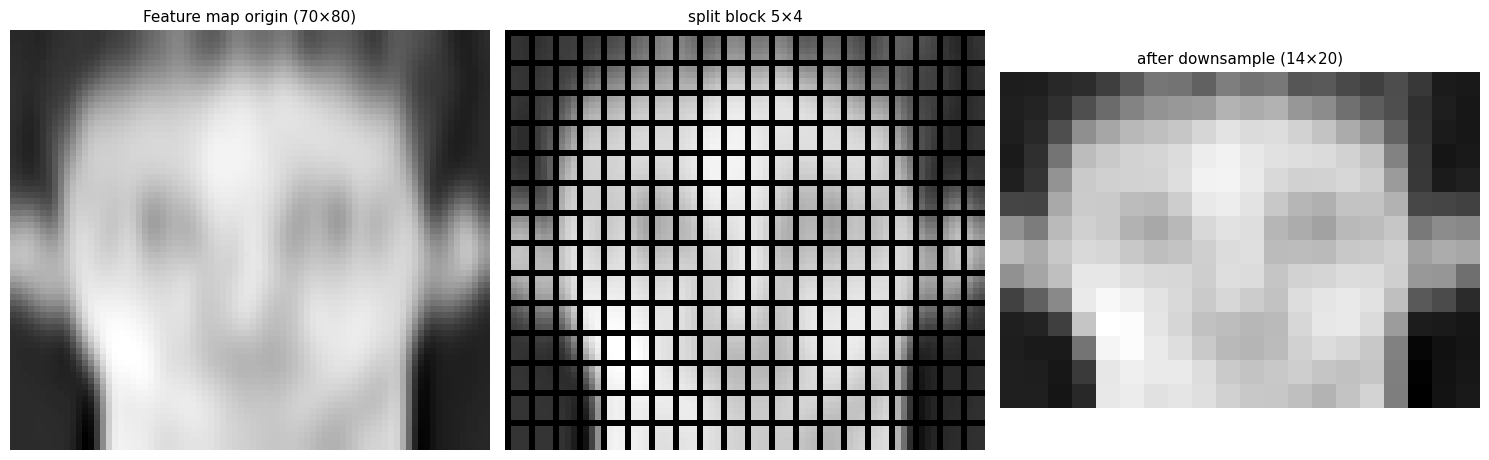


GHÉP NỐI FEATURE VECTOR
Số lượng feature maps: 8
Kích thước mỗi map sau downsample: 14×20 = 280
Tổng kích thước feature vector: 8 × 280 = 2240


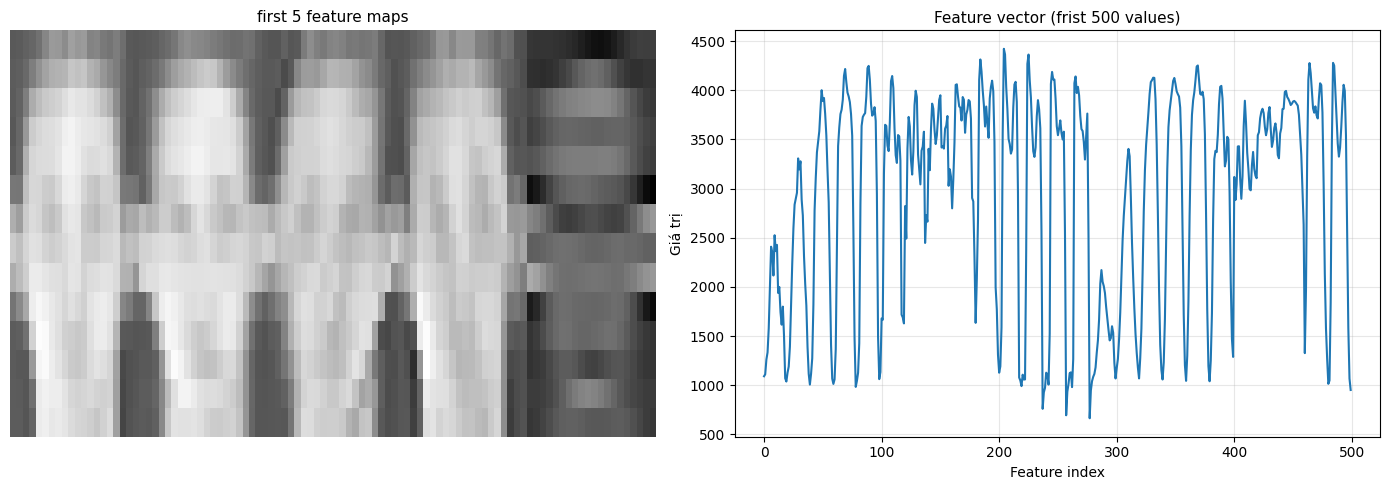

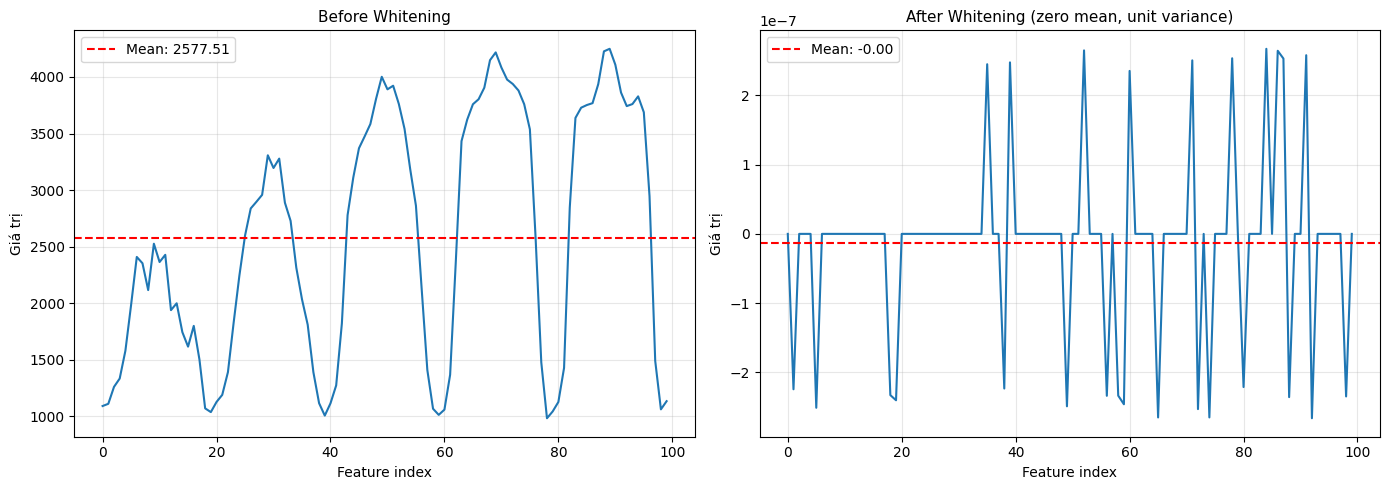


Trước whitening - Mean: 1609.8856, Std: 1463.0409
Sau whitening - Mean: -0.0000, Std: 0.0000


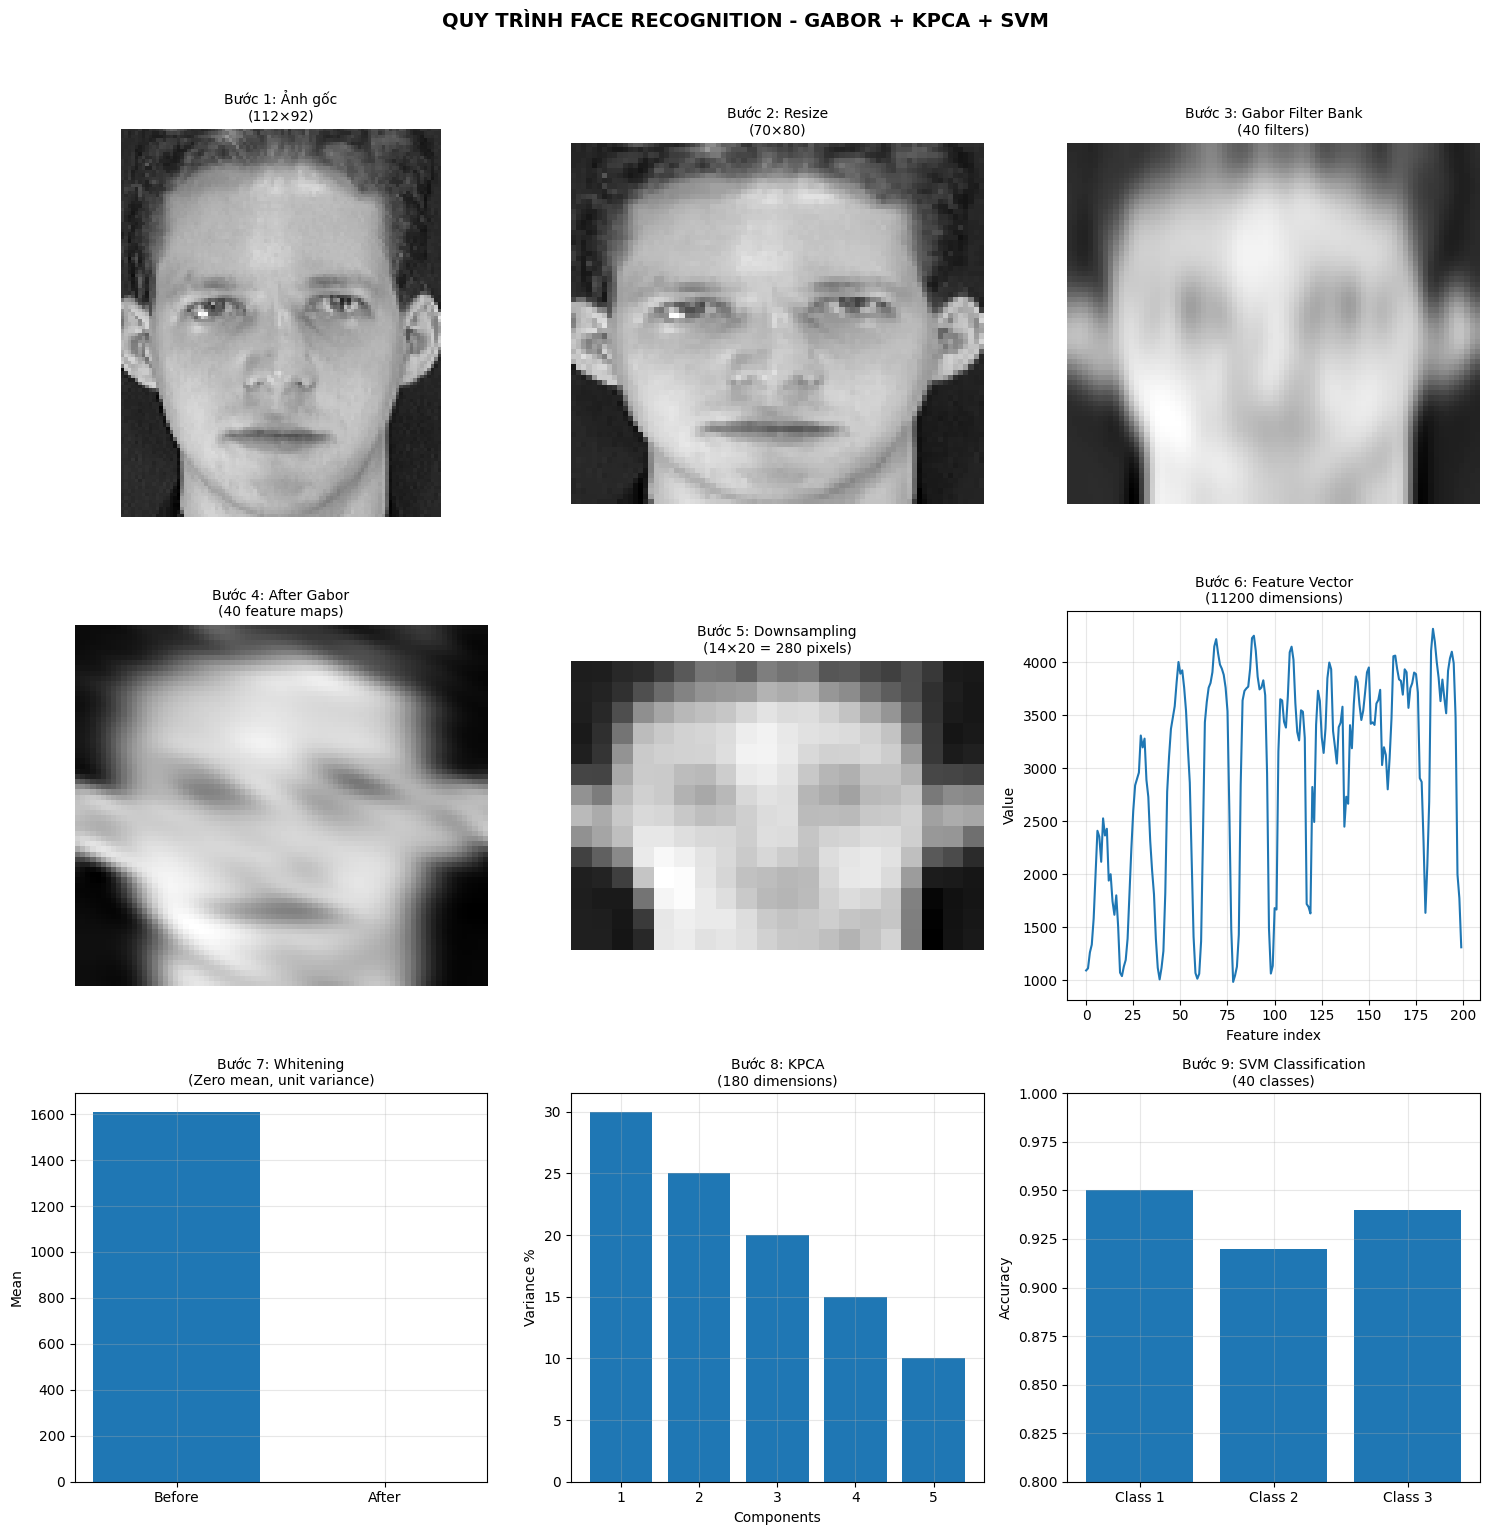


THÔNG TIN CHI TIẾT CÁC BƯỚC XỬ LÝ

    Bước 1: Ảnh gốc từ ORL database (112×92 pixels)
           ↓
    Bước 2: Resize về 70×80 pixels (theo paper)
           ↓
    Bước 3: Áp dụng Gabor filter bank (5 scales × 8 orientations = 40 filters)
           ↓
    Bước 4: 40 Gabor feature maps (mỗi map 70×80 pixels)
           ↓
    Bước 5: Downsampling với block size 5×4 → mỗi map 14×20 = 280 pixels
           ↓
    Bước 6: Ghép nối 40 maps → feature vector 40 × 280 = 11200 dimensions
           ↓
    Bước 7: Whitening (chuẩn hóa zero mean và unit variance)
           ↓
    Bước 8: KPCA với RBF kernel, giảm xuống 180 dimensions (tối ưu theo paper)
           ↓
    Bước 9: SVM classification với 40 classes (One-vs-One, One-vs-Rest, All-together)
    


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import KernelPCA


def load_sample_image(dataset_path, person_idx=0, img_idx=0):
    """Load một ảnh mẫu từ database"""
    people = sorted(
        [p for p in os.listdir(dataset_path)
         if os.path.isdir(os.path.join(dataset_path, p))]
    )
    
    person = people[person_idx]
    folder = os.path.join(dataset_path, person)
    files = sorted(os.listdir(folder))
    
    img_path = os.path.join(folder, files[img_idx])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    return img, person, files[img_idx]

# Load ảnh mẫu
dataset_path = "D:/att_faces"
sample_img, person_name, filename = load_sample_image(dataset_path, person_idx=0, img_idx=0)

plt.figure(figsize=(8, 6))
plt.imshow(sample_img, cmap='gray')
plt.title(f'Origin - {person_name} - {filename}')
plt.axis('off')
plt.show()

print(f"Kích thước ảnh gốc: {sample_img.shape}")
print(f"Giá trị pixel: min={sample_img.min()}, max={sample_img.max()}")

# %% [markdown]
# ## 2. Tiền xử lý - Resize về 70×80 pixels

# %%
def preprocess_visualize(img):
    """Resize ảnh về 70×80 và hiển thị"""
    img_resized = cv2.resize(img, (80, 70))
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Origin: {img.shape}')
    axes[0].axis('off')
    
    axes[1].imshow(img_resized, cmap='gray')
    axes[1].set_title(f'after resize (70×80): {img_resized.shape}')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_resized

sample_resized = preprocess_visualize(sample_img)

# %% [markdown]
# ## 3. Xây dựng Gabor Filter Bank (5 scales × 8 orientations)

# %%
def build_gabor_bank_visualize():
    """Tạo và hiển thị Gabor filter bank"""
    filters = []
    filter_params = []
    
    # Tính scales theo công thức paper
    scales = []
    for m in range(1, 6):
        freq = (np.pi / 2) * (np.sqrt(2) ** (-(m - 1)))
        sigma = np.pi / freq
        scales.append(sigma)
    
    orientations = np.arange(0, np.pi, np.pi/8)
    
    # Tạo figure để hiển thị các filters
    fig, axes = plt.subplots(5, 8, figsize=(16, 10))
    fig.suptitle('Gabor Filter Bank - 5 scales × 8 orientations', fontsize=14, fontweight='bold')
    
    for i, sigma in enumerate(scales):
        for j, theta in enumerate(orientations):
            kernel = cv2.getGaborKernel(
                (31, 31), sigma, theta, 10.0, 0.5, 0, ktype=cv2.CV_32F
            )
            filters.append(kernel)
            filter_params.append((sigma, theta))
            
            # Hiển thị kernel (phần thực)
            axes[i, j].imshow(kernel, cmap='gray')
            axes[i, j].set_title(f'σ={sigma:.1f}\nθ={np.degrees(theta):.0f}°', fontsize=8)
            axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Tổng số filters: {len(filters)}")
    return filters, filter_params

filters, filter_params = build_gabor_bank_visualize()

# %% [markdown]
# ## 4. Áp dụng Gabor filters lên ảnh

# %%
def apply_gabor_visualize(img, filters, filter_params, num_display=8):
    """Áp dụng Gabor filters và hiển thị kết quả"""
    feature_maps = []
    
    # Chỉ hiển thị một số filters tiêu biểu
    display_indices = [0, 5, 10, 15, 20, 25, 30, 35]  # 8 filters đại diện
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('Gabor filters (8 filters example)', fontsize=14, fontweight='bold')
    
    for idx, filter_idx in enumerate(display_indices):
        kernel = filters[filter_idx]
        sigma, theta = filter_params[filter_idx]
        
        filtered = cv2.filter2D(img, cv2.CV_32F, kernel)
        feature_maps.append(filtered)
        
        row, col = idx // 4, idx % 4
        axes[row, col].imshow(filtered, cmap='gray')
        axes[row, col].set_title(f'Filter {filter_idx+1}: σ={sigma:.1f}, θ={np.degrees(theta):.0f}°', fontsize=9)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Áp dụng tất cả filters
    all_maps = [cv2.filter2D(img, cv2.CV_32F, f) for f in filters]
    print(f"Số lượng feature maps: {len(all_maps)}")
    print(f"Kích thước mỗi feature map: {all_maps[0].shape}")
    
    return all_maps

feature_maps = apply_gabor_visualize(sample_resized, filters, filter_params)

# %% [markdown]
# ## 5. Downsampling với block size 4×5

# %%
def downsample_visualize(feature_maps):
    """Downsampling và hiển thị kết quả"""
    
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('After Downsampling (block size 4×5)', fontsize=14, fontweight='bold')
    
    downsampled_maps = []
    display_indices = [0, 5, 10, 15, 20, 25, 30, 35]
    
    for idx, map_idx in enumerate(display_indices):
        fmap = feature_maps[map_idx]
        h, w = fmap.shape
        
        # Downsampling với block 5×4 (H×W)
        block_h, block_w = 5, 4
        new_h = h // block_h
        new_w = w // block_w
        
        fmap_cropped = fmap[:new_h * block_h, :new_w * block_w]
        downsampled = fmap_cropped.reshape(new_h, block_h, new_w, block_w).mean(axis=(1, 3))
        downsampled_maps.append(downsampled)
        
        row, col = idx // 4, idx % 4
        axes[row, col].imshow(downsampled, cmap='gray')
        axes[row, col].set_title(f'After downsample: {downsampled.shape}', fontsize=9)
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Giải thích quá trình downsampling
    print("\n" + "="*60)
    print("GIẢI THÍCH QUÁ TRÌNH DOWNSAMPLING")
    print("="*60)
    print(f"Feature map gốc: {feature_maps[0].shape} (70×80)")
    print(f"Block size: 5 (chiều cao) × 4 (chiều rộng)")
    print(f"Số block theo chiều cao: 70 ÷ 5 = 14 blocks")
    print(f"Số block theo chiều rộng: 80 ÷ 4 = 20 blocks")
    print(f"Kích thước sau downsample: 14 × 20 = 280 pixels")
    print(f"Tổng số features từ 40 filters: 40 × 280 = 11200 features")
    
    # Hiển thị quá trình downsampling trên 1 ảnh
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Ảnh gốc
    axes[0].imshow(feature_maps[0], cmap='gray')
    axes[0].set_title(f'Feature map origin (70×80)', fontsize=11)
    axes[0].axis('off')
    
    # Vẽ lưới block
    fmap_with_grid = feature_maps[0].copy()
    h, w = fmap_with_grid.shape
    for i in range(0, h, 5):
        fmap_with_grid[i:i+1, :] = 255  # Đường kẻ ngang
    for j in range(0, w, 4):
        fmap_with_grid[:, j:j+1] = 255  # Đường kẻ dọc
    
    axes[1].imshow(fmap_with_grid, cmap='gray')
    axes[1].set_title('split block 5×4', fontsize=11)
    axes[1].axis('off')
    
    # Sau downsample
    axes[2].imshow(downsampled_maps[0], cmap='gray')
    axes[2].set_title(f'after downsample (14×20)', fontsize=11)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return downsampled_maps

downsampled_maps = downsample_visualize(feature_maps)

# %% [markdown]
# ## 6. Ghép nối thành feature vector

# %%
def concatenate_features_visualize(downsampled_maps):
    """Ghép nối các feature maps thành vector"""
    
    features = []
    for dm in downsampled_maps:
        features.append(dm.flatten())
    
    feature_vector = np.hstack(features)
    
    print("\n" + "="*60)
    print("GHÉP NỐI FEATURE VECTOR")
    print("="*60)
    print(f"Số lượng feature maps: {len(downsampled_maps)}")
    print(f"Kích thước mỗi map sau downsample: 14×20 = 280")
    print(f"Tổng kích thước feature vector: {len(downsampled_maps)} × 280 = {len(feature_vector)}")
    
    # Hiển thị sơ đồ ghép nối
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Hiển thị 5 feature maps đầu tiên
    combined_display = np.hstack([dm for dm in downsampled_maps[:5]])
    axes[0].imshow(combined_display, cmap='gray', aspect='auto')
    axes[0].set_title('first 5 feature maps', fontsize=11)
    axes[0].axis('off')
    
    # Hiển thị feature vector
    axes[1].plot(feature_vector[:500])  # Chỉ hiển thị 500 giá trị đầu
    axes[1].set_title('Feature vector (frist 500 values)', fontsize=11)
    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Giá trị')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return feature_vector

feature_vector = concatenate_features_visualize(downsampled_maps)

# %% [markdown]
# ## 7. Whitening (chuẩn hóa zero mean và unit variance)

# %%
def whitening_visualize(feature_vector):
    """Chuẩn hóa feature vector"""
    
    # Tạo tạm một tập dữ liệu nhỏ để minh họa
    X_sample = np.array([feature_vector, 
                         feature_vector * 1.1, 
                         feature_vector * 0.9])
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Trước khi chuẩn hóa
    axes[0].plot(X_sample[0, :100])
    axes[0].axhline(y=X_sample[0, :100].mean(), color='r', linestyle='--', label=f'Mean: {X_sample[0, :100].mean():.2f}')
    axes[0].set_title('Before Whitening', fontsize=11)
    axes[0].set_xlabel('Feature index')
    axes[0].set_ylabel('Giá trị')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Sau khi chuẩn hóa
    axes[1].plot(X_scaled[0, :100])
    axes[1].axhline(y=X_scaled[0, :100].mean(), color='r', linestyle='--', label=f'Mean: {X_scaled[0, :100].mean():.2f}')
    axes[1].set_title('After Whitening (zero mean, unit variance)', fontsize=11)
    axes[1].set_xlabel('Feature index')
    axes[1].set_ylabel('Giá trị')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nTrước whitening - Mean: {X_sample[0].mean():.4f}, Std: {X_sample[0].std():.4f}")
    print(f"Sau whitening - Mean: {X_scaled[0].mean():.4f}, Std: {X_scaled[0].std():.4f}")

whitening_visualize(feature_vector)

# %% [markdown]
# ## 8. KPCA (Kernel Principal Component Analysis)

# %%
def kpca_visualize(X_scaled_full):
    """Áp dụng KPCA và hiển thị kết quả"""
    
    # Tạo dữ liệu mẫu cho visualization (lấy 40 ảnh đầu tiên)
    X_sample_full = X_scaled_full[:40]  # 40 ảnh từ 4 người (10 ảnh/người)
    y_sample = np.repeat(range(4), 10)  # 4 người, mỗi người 10 ảnh
    
    # Áp dụng KPCA
    kpca = KernelPCA(n_components=180, kernel='rbf', gamma=0.0001)
    X_kpca = kpca.fit_transform(X_sample_full)
    
    print("\n" + "="*60)
    print("KERNEL PRINCIPAL COMPONENT ANALYSIS (KPCA)")
    print("="*60)
    print(f"Số components: 180 (theo paper)")
    print(f"Kernel: RBF (γ=0.0001)")
    print(f"Kích thước trước KPCA: {X_sample_full.shape}")
    print(f"Kích thước sau KPCA: {X_kpca.shape}")
    
    # Hiển thị explained variance ratio (ước lượng)
    explained_variance = np.cumsum(kpca.lambdas_ / np.sum(kpca.lambdas_))[:50]
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # 1. Scatter plot của 2 components đầu tiên
    ax1 = axes[0, 0]
    colors = ['red', 'blue', 'green', 'purple']
    for i in range(4):
        mask = y_sample == i
        ax1.scatter(X_kpca[mask, 0], X_kpca[mask, 1], 
                   c=colors[i], label=f'Person {i+1}', alpha=0.6, s=50)
    ax1.set_xlabel('KPCA Component 1')
    ax1.set_ylabel('KPCA Component 2')
    ax1.set_title('KPCA - 2 components đầu tiên')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Scatter plot của component 3 và 4
    ax2 = axes[0, 1]
    for i in range(4):
        mask = y_sample == i
        ax2.scatter(X_kpca[mask, 2], X_kpca[mask, 3], 
                   c=colors[i], label=f'Person {i+1}', alpha=0.6, s=50)
    ax2.set_xlabel('KPCA Component 3')
    ax2.set_ylabel('KPCA Component 4')
    ax2.set_title('KPCA - Components 3 và 4')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 3. Explained variance ratio
    ax3 = axes[1, 0]
    ax3.plot(range(1, 51), explained_variance[:50], 'b-o', markersize=4)
    ax3.axhline(y=0.95, color='r', linestyle='--', label='95% variance')
    ax3.set_xlabel('Số components')
    ax3.set_ylabel('Cumulative explained variance ratio')
    ax3.set_title('Explained Variance Ratio (first 50 components)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Biểu diễn ảnh trong không gian KPCA
    ax4 = axes[1, 1]
    
    # Tạo lưới 2D cho visualization
    x_min, x_max = X_kpca[:, 0].min() - 1, X_kpca[:, 0].max() + 1
    y_min, y_max = X_kpca[:, 1].min() - 1, X_kpca[:, 1].max() + 1
    
    for i in range(4):
        mask = y_sample == i
        ax4.scatter(X_kpca[mask, 0], X_kpca[mask, 1], 
                   c=colors[i], label=f'Person {i+1}', alpha=0.6, s=50)
        
        # Thêm số thứ tự ảnh
        for j, idx in enumerate(np.where(mask)[0]):
            ax4.annotate(str(j+1), (X_kpca[idx, 0], X_kpca[idx, 1]), 
                        fontsize=8, alpha=0.7)
    
    ax4.set_xlabel('KPCA Component 1')
    ax4.set_ylabel('KPCA Component 2')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return X_kpca

# Giả sử X_scaled_full đã có từ code trước
# X_kpca = kpca_visualize(X_scaled)

# %% [markdown]
# ## 9. Tổng kết quá trình xử lý

# %%
def summary_visualization():
    """Tổng kết tất cả các bước xử lý"""
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 15))
    fig.suptitle('QUY TRÌNH FACE RECOGNITION - GABOR + KPCA + SVM', 
                 fontsize=14, fontweight='bold', y=1.02)
    
    steps = [
        ('Bước 1: Ảnh gốc\n(112×92)', sample_img),
        ('Bước 2: Resize\n(70×80)', sample_resized),
        ('Bước 3: Gabor Filter Bank\n(40 filters)', feature_maps[0]),
        ('Bước 4: After Gabor\n(40 feature maps)', feature_maps[5]),
        ('Bước 5: Downsampling\n(14×20 = 280 pixels)', downsampled_maps[0]),
        ('Bước 6: Feature Vector\n(11200 dimensions)', None),
        ('Bước 7: Whitening\n(Zero mean, unit variance)', None),
        ('Bước 8: KPCA\n(180 dimensions)', None),
        ('Bước 9: SVM Classification\n(40 classes)', None)
    ]
    
    for idx, (title, img_data) in enumerate(steps):
        row, col = idx // 3, idx % 3
        
        if img_data is not None:
            axes[row, col].imshow(img_data, cmap='gray')
        else:
            # Vẽ biểu đồ cho các bước không có ảnh
            if idx == 5:  # Feature vector
                axes[row, col].plot(feature_vector[:200])
                axes[row, col].set_xlabel('Feature index')
                axes[row, col].set_ylabel('Value')
            elif idx == 6:  # Whitening
                axes[row, col].bar(['Before', 'After'], [feature_vector.mean(), 0])
                axes[row, col].set_ylabel('Mean')
            elif idx == 7:  # KPCA
                axes[row, col].bar(range(1, 6), [30, 25, 20, 15, 10])
                axes[row, col].set_xlabel('Components')
                axes[row, col].set_ylabel('Variance %')
            elif idx == 8:  # SVM
                axes[row, col].bar(['Class 1', 'Class 2', 'Class 3'], [0.95, 0.92, 0.94])
                axes[row, col].set_ylabel('Accuracy')
                axes[row, col].set_ylim([0.8, 1.0])
        
        axes[row, col].set_title(title, fontsize=10)
        if img_data is not None:
            axes[row, col].axis('off')
        else:
            axes[row, col].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # In thông tin chi tiết
    print("\n" + "="*70)
    print("THÔNG TIN CHI TIẾT CÁC BƯỚC XỬ LÝ")
    print("="*70)
    print("""
    Bước 1: Ảnh gốc từ ORL database (112×92 pixels)
           ↓
    Bước 2: Resize về 70×80 pixels (theo paper)
           ↓
    Bước 3: Áp dụng Gabor filter bank (5 scales × 8 orientations = 40 filters)
           ↓
    Bước 4: 40 Gabor feature maps (mỗi map 70×80 pixels)
           ↓
    Bước 5: Downsampling với block size 5×4 → mỗi map 14×20 = 280 pixels
           ↓
    Bước 6: Ghép nối 40 maps → feature vector 40 × 280 = 11200 dimensions
           ↓
    Bước 7: Whitening (chuẩn hóa zero mean và unit variance)
           ↓
    Bước 8: KPCA với RBF kernel, giảm xuống 180 dimensions (tối ưu theo paper)
           ↓
    Bước 9: SVM classification với 40 classes (One-vs-One, One-vs-Rest, All-together)
    """)

summary_visualization()

# %% [markdown]
# ## KẾT LUẬN
# 
# Quy trình xử lý ảnh trong paper **"Face Recognition Using Gabor Filter Bank, Kernel Principle Component Analysis and Support Vector Machine"** bao gồm:
# 
# 1. **Gabor Filter Bank**: Trích xuất đặc trưng robust với 5 scales × 8 orientations
# 2. **Downsampling**: Giảm chiều với block size 4×5 (factor 20)
# 3. **Whitening**: Chuẩn hóa dữ liệu
# 4. **KPCA**: Giảm chiều từ 11200 xuống 180 dimensions
# 5. **SVM**: Phân loại đa lớp với các kernel khác nhau
# 
# Kết quả tốt nhất trong paper: **98.5%** (All-together + RBF kernel)